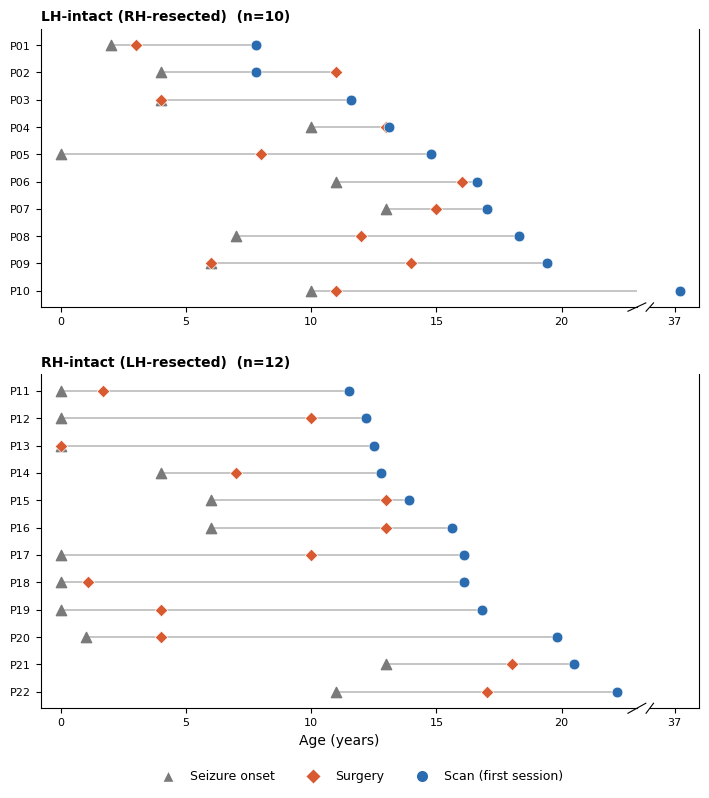

In [8]:
#!/usr/bin/env python
"""
Patient clinical timeline (Liu-style, real age axis). CORRECTED COHORT.
sub-076 reclassified RH-intact (left resection); LH=10, RH=12.
Two panels: LH-intact (RH-resected) / RH-intact (LH-resected).
Markers: seizure onset (^), surgery (D), scan = first session (o).
Broken x-axis for P10 / sub-091 (scan 37.3).
"""
import matplotlib.pyplot as plt
from matplotlib import gridspec

# (label, seizure_y, surgery_y, scan_y).  surgery_y may be a tuple (multiple ops).
LH = [  # LH-intact, by first-session scan age  (10)
    ("P01",  2.0,  3.0,  7.8),   # 077
    ("P02",  4.0, 11.0,  7.8),   # 004
    ("P03",  4.0,  4.0, 11.6),   # 075
    ("P04", 10.0, 13.0, 13.1),   # 074
    ("P05",  0.0,  8.0, 14.8),   # 008
    ("P06", 11.0, 16.0, 16.6),   # 079
    ("P07", 13.0, 15.0, 17.0),   # 039
    ("P08",  7.0, 12.0, 18.3),   # 089
    ("P09",  6.0, (6.0, 14.0), 19.4),  # 005
    ("P10", 10.0, 11.0, 37.3),   # 091
]
RH = [  # RH-intact, by first-session scan age  (12)
    ("P11",  0.0,  1.7, 11.5),   # 099
    ("P12",  0.0, 10.0, 12.2),   # 069
    ("P13",  0.0,  0.0, 12.5),   # 044
    ("P14",  4.0,  7.0, 12.8),   # 010
    ("P15",  6.0, 13.0, 13.9),   # 021
    ("P16",  6.0, 13.0, 15.6),   # 090
    ("P17",  0.0, 10.0, 16.1),   # 076  <-- moved here
    ("P18",  0.0,  1.1, 16.1),   # 108
    ("P19",  0.0,  4.0, 16.8),   # 066
    ("P20",  1.0,  4.0, 19.8),   # 092
    ("P21", 13.0, 18.0, 20.5),   # 082
    ("P22", 11.0, 17.0, 22.2),   # 078
]

C_SEIZ, C_SURG, C_SCAN = "#7A7A7A", "#D85A30", "#2B6CB0"
LINE = "#BBBBBB"
MAIN_MAX, BRK_LO, BRK_HI = 23, 35.5, 38.5

def draw_panel(ax_main, ax_brk, rows, title):
    n = len(rows)
    for i, (lab, sz, su, sc) in enumerate(rows):
        y = n - 1 - i
        su_list = [] if su is None else (list(su) if isinstance(su,(tuple,list)) else [su])
        pts = [v for v in ([sz]+su_list+[sc]) if v is not None]
        ax_main.plot([min(pts), min(max(pts), MAIN_MAX)], [y, y], color=LINE, lw=1.2, zorder=1)
        for ax in (ax_main, ax_brk):
            if sz is not None:
                ax.scatter(sz, y, marker="^", s=55, color=C_SEIZ, zorder=3)
            for sv in su_list:
                ax.scatter(sv, y, marker="D", s=42, color=C_SURG, zorder=3, edgecolors="white", linewidths=0.5)
            ax.scatter(sc, y, marker="o", s=60, color=C_SCAN, zorder=3, edgecolors="white", linewidths=0.5)
    ax_main.set_yticks(range(n)); ax_main.set_yticklabels([r[0] for r in reversed(rows)], fontsize=8)
    ax_main.set_ylim(-0.6, n-0.4); ax_main.set_xlim(-0.8, MAIN_MAX)
    ax_brk.set_xlim(BRK_LO, BRK_HI); ax_brk.set_yticks([]); ax_brk.set_ylim(-0.6, n-0.4)
    ax_main.set_title(title, fontsize=10, fontweight="bold", loc="left")
    ax_main.spines["right"].set_visible(False); ax_brk.spines["left"].set_visible(False)
    ax_brk.set_xticks([37])
    for ax in (ax_main, ax_brk):
        ax.spines["top"].set_visible(False); ax.tick_params(labelsize=8)
    d=.015; kw=dict(transform=ax_main.transAxes,color="k",clip_on=False,lw=0.8)
    ax_main.plot((1-d,1+d),(-d,d),**kw); kw.update(transform=ax_brk.transAxes); ax_brk.plot((-d*5,d*5),(-d,d),**kw)

fig = plt.figure(figsize=(8.5, 8.6))
gs = gridspec.GridSpec(2, 2, width_ratios=[12,1], height_ratios=[10,12], wspace=0.04, hspace=0.22)
axL, axLb = fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])
axR, axRb = fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])
draw_panel(axL, axLb, LH, "LH-intact (RH-resected)  (n=10)")
draw_panel(axR, axRb, RH, "RH-intact (LH-resected)  (n=12)")
axR.set_xlabel("Age (years)", fontsize=10)
handles = [
    plt.Line2D([],[],marker="^",color="w",markerfacecolor=C_SEIZ,ms=9,label="Seizure onset"),
    plt.Line2D([],[],marker="D",color="w",markerfacecolor=C_SURG,ms=8,label="Surgery"),
    plt.Line2D([],[],marker="o",color="w",markerfacecolor=C_SCAN,ms=9,label="Scan (first session)"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.5,-0.01))
fig.subplots_adjust(bottom=0.09)

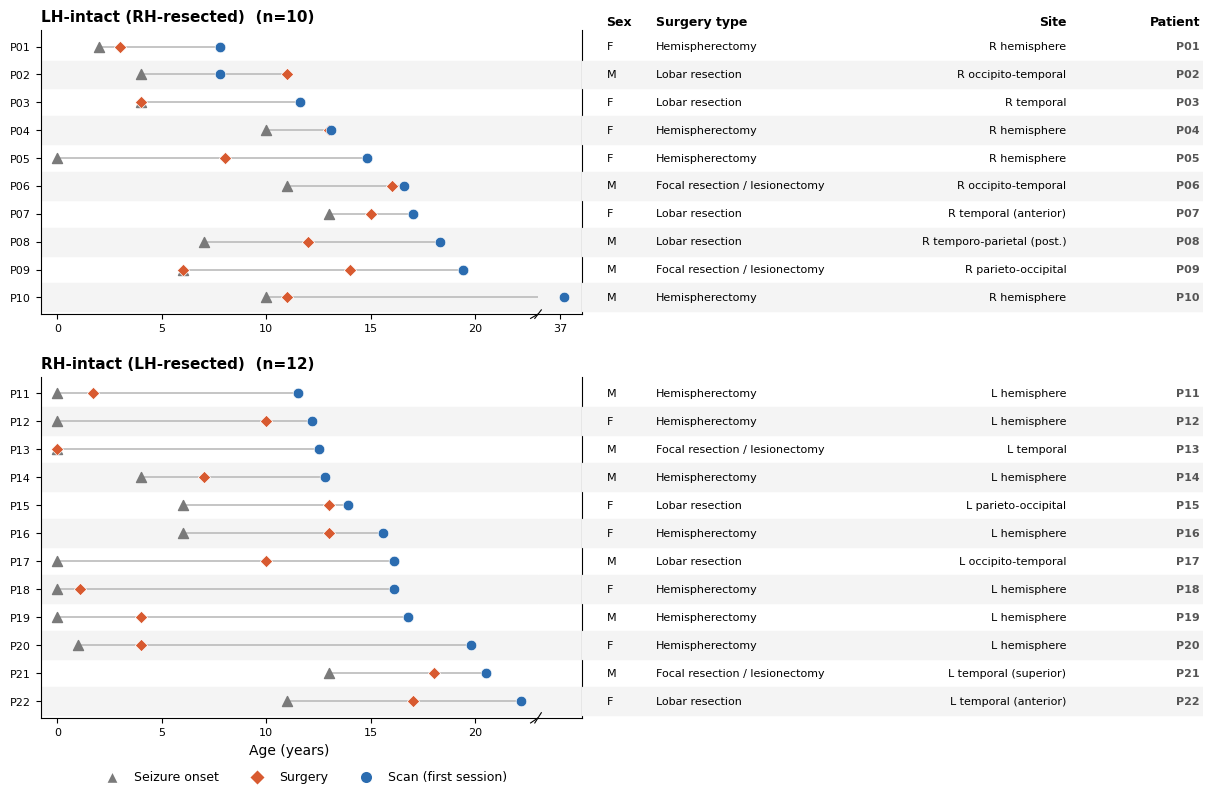

In [3]:
#!/usr/bin/env python
"""
Combined cross-sectional figure: per-patient timeline (left) flowing into a
metadata table (right), shared rows. White table background, faint alternating
row bands carry the eye across the seam. Two panels: LH-intact / RH-intact.
Broken x-axis (left only) for the 37y scan (P10).
"""
import matplotlib.pyplot as plt
from matplotlib import gridspec

# (pid, sex, surgery, site, seizure, surgery_age, scan)   surgery_age may be tuple
LH = [
    ("P01","F","Hemispherectomy",                "R hemisphere",                2.0,  3.0,  7.8),
    ("P02","M","Lobar resection",                "R occipito-temporal",         4.0, 11.0,  7.8),
    ("P03","F","Lobar resection",                "R temporal",                  4.0,  4.0, 11.6),
    ("P04","F","Hemispherectomy",                "R hemisphere",               10.0, 13.0, 13.1),
    ("P05","F","Hemispherectomy",                "R hemisphere",                0.0,  8.0, 14.8),
    ("P06","M","Focal resection / lesionectomy", "R occipito-temporal",        11.0, 16.0, 16.6),
    ("P07","F","Lobar resection",                "R temporal (anterior)",      13.0, 15.0, 17.0),
    ("P08","M","Lobar resection",                "R temporo-parietal (post.)",  7.0, 12.0, 18.3),
    ("P09","M","Focal resection / lesionectomy", "R parieto-occipital",         6.0,(6.0,14.0),19.4),
    ("P10","M","Hemispherectomy",                "R hemisphere",               10.0, 11.0, 37.3),
]
RH = [
    ("P11","M","Hemispherectomy",                "L hemisphere",                0.0,  1.7, 11.5),
    ("P12","F","Hemispherectomy",                "L hemisphere",                0.0, 10.0, 12.2),
    ("P13","M","Focal resection / lesionectomy", "L temporal",                  0.0,  0.0, 12.5),
    ("P14","M","Hemispherectomy",                "L hemisphere",                4.0,  7.0, 12.8),
    ("P15","F","Lobar resection",                "L parieto-occipital",         6.0, 13.0, 13.9),
    ("P16","F","Hemispherectomy",                "L hemisphere",                6.0, 13.0, 15.6),
    ("P17","M","Lobar resection",                "L occipito-temporal",         0.0, 10.0, 16.1),
    ("P18","F","Hemispherectomy",                "L hemisphere",                0.0,  1.1, 16.1),
    ("P19","M","Hemispherectomy",                "L hemisphere",                0.0,  4.0, 16.8),
    ("P20","F","Hemispherectomy",                "L hemisphere",                1.0,  4.0, 19.8),
    ("P21","M","Focal resection / lesionectomy", "L temporal (superior)",      13.0, 18.0, 20.5),
    ("P22","F","Lobar resection",                "L temporal (anterior)",      11.0, 17.0, 22.2),
]

C_SEIZ, C_SURG, C_SCAN = "#7A7A7A", "#D85A30", "#2B6CB0"
LINE, BAND = "#BBBBBB", "#F4F4F4"
MAIN_MAX, BRK_LO, BRK_HI = 23, 35.5, 38.5
# table column x-positions (axes fraction) and alignment
COLX = {"Sex":0.04, "Surgery type":0.12, "Site":0.78, "Patient":0.995}

def bands(ax, n):
    for r in range(n):
        if r % 2 == 0:
            ax.axhspan(r-0.5, r+0.5, color=BAND, zorder=0)

def draw_timeline(axm, axb, rows):
    n = len(rows); bands(axm, n); bands(axb, n)
    for i, row in enumerate(rows):
        pid, _, _, _, sz, su, sc = row; y = n-1-i
        su_list = list(su) if isinstance(su,(tuple,list)) else [su]
        pts = [sz]+su_list+[sc]
        axm.plot([min(pts), min(max(pts),MAIN_MAX)], [y,y], color=LINE, lw=1.2, zorder=1)
        for ax in (axm, axb):
            ax.scatter(sz, y, marker="^", s=52, color=C_SEIZ, zorder=3)
            for sv in su_list:
                ax.scatter(sv, y, marker="D", s=40, color=C_SURG, zorder=3, edgecolors="white", linewidths=.5)
            ax.scatter(sc, y, marker="o", s=58, color=C_SCAN, zorder=3, edgecolors="white", linewidths=.5)
    axm.set_yticks(range(n)); axm.set_yticklabels([r[0] for r in reversed(rows)], fontsize=8)
    axm.set_ylim(-0.6, n-0.4); axm.set_xlim(-0.8, MAIN_MAX)
    axb.set_xlim(BRK_LO, BRK_HI); axb.set_yticks([]); axb.set_ylim(-0.6, n-0.4); axb.set_xticks([37])
    axm.spines["right"].set_visible(False); axb.spines["left"].set_visible(False)
    for ax in (axm, axb): ax.spines["top"].set_visible(False); ax.tick_params(labelsize=8)
    d=.015; kw=dict(transform=axm.transAxes,color="k",clip_on=False,lw=.8)
    axm.plot((1-d,1+d),(-d,d),**kw); kw.update(transform=axb.transAxes); axb.plot((-d*5,d*5),(-d,d),**kw)

def draw_table(ax, rows, header=False):
    n = len(rows); bands(ax, n)
    ax.set_xlim(0,1); ax.set_ylim(-0.6, n-0.4); ax.axis("off")
    for i, row in enumerate(rows):
        pid, sex, surg, site = row[0], row[1], row[2], row[3]; y = n-1-i
        ax.text(COLX["Sex"], y, sex, ha="left", va="center", fontsize=8)
        ax.text(COLX["Surgery type"], y, surg, ha="left", va="center", fontsize=8)
        ax.text(COLX["Site"], y, site, ha="right", va="center", fontsize=8)
        ax.text(COLX["Patient"], y, pid, ha="right", va="center", fontsize=8, fontweight="bold", color="#555555")
    if header:
        for label, x in COLX.items():
            ha = "right" if label in ("Site","Patient") else "left"
            ax.text(x, n-0.35, label, ha=ha, va="bottom", fontsize=9, fontweight="bold",
                    transform=ax.transData, clip_on=False)

fig = plt.figure(figsize=(15, 8.6))
gs = gridspec.GridSpec(2, 3, width_ratios=[8, 0.7, 10], height_ratios=[10,12],
                       wspace=0.0, hspace=0.20)
# LH
axLm, axLb, axLt = fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1]), fig.add_subplot(gs[0,2])
draw_timeline(axLm, axLb, LH); draw_table(axLt, LH, header=True)
axLm.set_title("LH-intact (RH-resected)  (n=10)", fontsize=11, fontweight="bold", loc="left")
# RH
axRm, axRb, axRt = fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1]), fig.add_subplot(gs[1,2])
draw_timeline(axRm, axRb, RH); draw_table(axRt, RH)
axRb.set_xticks([])
axRm.set_title("RH-intact (LH-resected)  (n=12)", fontsize=11, fontweight="bold", loc="left")
axRm.set_xlabel("Age (years)", fontsize=10)

handles = [
    plt.Line2D([],[],marker="^",color="w",markerfacecolor=C_SEIZ,ms=9,label="Seizure onset"),
    plt.Line2D([],[],marker="D",color="w",markerfacecolor=C_SURG,ms=8,label="Surgery"),
    plt.Line2D([],[],marker="o",color="w",markerfacecolor=C_SCAN,ms=9,label="Scan (first session)"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.30,-0.01))
fig.subplots_adjust(bottom=0.08)

Text(0.0, 1.0, 'Controls + patient scan age')

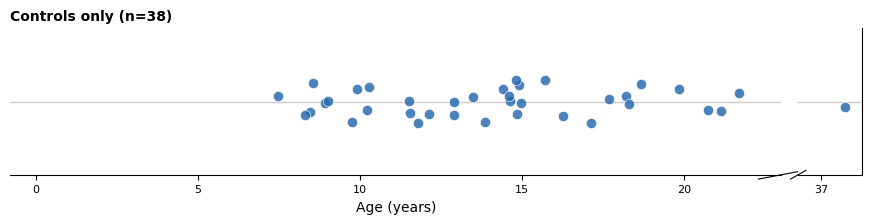

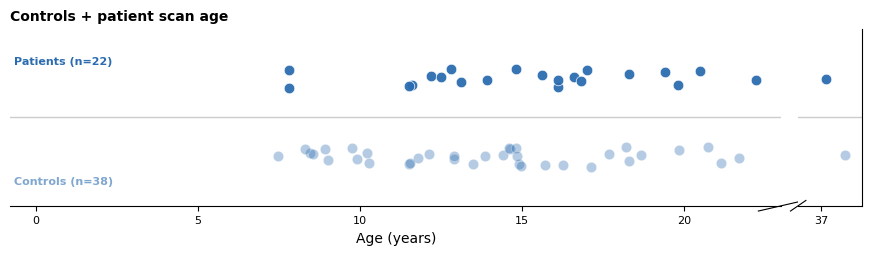

In [10]:
#!/usr/bin/env python
"""Control ages as a jittered strip on a single age line (matches timeline dot vocabulary).
Two variants: (1) controls only (blue), (2) controls + patient scan dots (patients solid blue,
controls translucent blue)."""
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

CSV="/user_data/csimmon2/git_repos/sym_pt/sub_info.csv"; CTRL_EXCLUDE={"sub-027","sub-084"}
C_SCAN="#2B6CB0"; MAIN_MAX,BRK_LO,BRK_HI=23,35.5,39.7
rng=np.random.default_rng(7)

df=pd.read_csv(CSV); ctrl=df[df["group"].str.lower()=="control"].copy()
ctrl=ctrl[~ctrl["sub"].isin(CTRL_EXCLUDE)]
ctrl["sesnum"]=ctrl["ses"].str.extract(r"(\d+)").astype(int)
ctrl=ctrl.sort_values("sesnum").drop_duplicates("sub",keep="first")
cage=ctrl["age"].values
pt=np.array([7.8,7.8,11.6,13.1,14.8,16.6,17.0,18.3,19.4,37.3,
             11.5,12.2,12.5,12.8,13.9,15.6,16.1,16.1,16.8,19.8,20.5,22.2])
def split(a): return a[a<=MAIN_MAX], a[a>=BRK_LO]

def break_axis(axm,axb,ylim):
    axm.set_xlim(-0.8,MAIN_MAX); axb.set_xlim(BRK_LO,BRK_HI)
    axm.spines["right"].set_visible(False); axb.spines["left"].set_visible(False)
    axm.set_yticks([]); axb.set_yticks([]); axb.set_xticks([37])
    for ax in (axm,axb):
        ax.spines["top"].set_visible(False); ax.spines["left"].set_visible(False)
        ax.set_ylim(*ylim); ax.tick_params(labelsize=8)
    d=.03; kw=dict(transform=axm.transAxes,color="k",clip_on=False,lw=.8)
    axm.plot((1-d,1+d),(-d,d),**kw); kw.update(transform=axb.transAxes); axb.plot((-d*4,d*4),(-d,d),**kw)
    axm.set_xlabel("Age (years)",fontsize=10)

# ---- Variant 1: controls only ----
f1=plt.figure(figsize=(11,1.9)); g=gridspec.GridSpec(1,2,width_ratios=[12,1],wspace=0.04)
axm,axb=f1.add_subplot(g[0]),f1.add_subplot(g[1])
axm.axhline(0,color="#CCCCCC",lw=1,zorder=0); axb.axhline(0,color="#CCCCCC",lw=1,zorder=0)
cm,cbk=split(cage)
axm.scatter(cm, rng.uniform(-.3,.3,len(cm)), s=55, color=C_SCAN, alpha=.85, edgecolors="white", linewidths=.5, zorder=3)
axb.scatter(cbk, rng.uniform(-.3,.3,len(cbk)), s=55, color=C_SCAN, alpha=.85, edgecolors="white", linewidths=.5, zorder=3)
break_axis(axm,axb,(-1,1))
axm.set_title(f"Controls only (n={len(cage)})",fontsize=10,fontweight="bold",loc="left")
# ---- Variant 2: controls + patients (patients y=+, controls y=-, both blue; controls translucent) ----
f2=plt.figure(figsize=(11,2.3)); g=gridspec.GridSpec(1,2,width_ratios=[12,1],wspace=0.04)
axm,axb=f2.add_subplot(g[0]),f2.add_subplot(g[1])
axm.axhline(0,color="#CCCCCC",lw=1,zorder=0); axb.axhline(0,color="#CCCCCC",lw=1,zorder=0)
pm,pbk=split(pt); cm,cbk=split(cage)
axm.scatter(pm, 0.45+rng.uniform(-.12,.12,len(pm)), s=58, color=C_SCAN, alpha=.95, edgecolors="white", linewidths=.5, zorder=3)
axm.scatter(cm,-0.45+rng.uniform(-.12,.12,len(cm)), s=55, color=C_SCAN, alpha=.35, edgecolors="white", linewidths=.5, zorder=3)
axb.scatter(pbk, 0.45+rng.uniform(-.05,.05,len(pbk)), s=58, color=C_SCAN, alpha=.95, edgecolors="white", linewidths=.5, zorder=3)
axb.scatter(cbk,-0.45+rng.uniform(-.05,.05,len(cbk)), s=55, color=C_SCAN, alpha=.35, edgecolors="white", linewidths=.5, zorder=3)
break_axis(axm,axb,(-1,1))
axm.text(0.005,.80,f"Patients (n={len(pt)})",transform=axm.transAxes,fontsize=8,color=C_SCAN,fontweight="bold")
axm.text(0.005,.12,f"Controls (n={len(cage)})",transform=axm.transAxes,fontsize=8,color=C_SCAN,alpha=.6,fontweight="bold")
axm.set_title("Controls + patient scan age",fontsize=10,fontweight="bold",loc="left")

Text(0.0, 1.0, 'Controls + patient scan age')

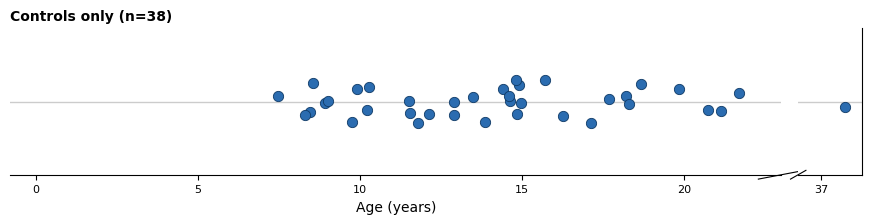

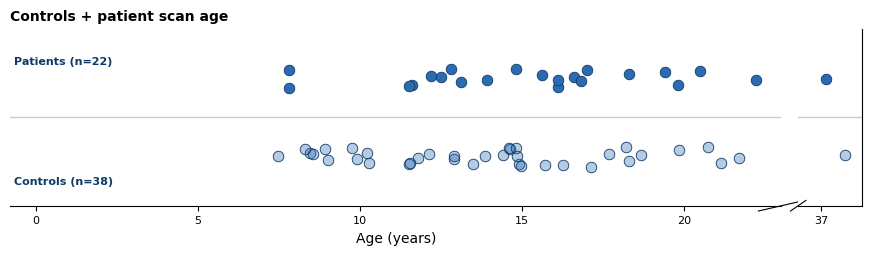

In [13]:
#!/usr/bin/env python
"""Control ages as a jittered strip on a single age line (matches timeline dot vocabulary).
Two variants: (1) controls only (blue), (2) controls + patient scan dots (patients solid blue,
controls translucent blue)."""
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

CSV="/user_data/csimmon2/git_repos/sym_pt/sub_info.csv"; CTRL_EXCLUDE={"sub-027","sub-084"}
C_SCAN="#2B6CB0"; C_EDGE="#0F3A66"; MAIN_MAX,BRK_LO,BRK_HI=23,35.5,39.7
rng=np.random.default_rng(7)

df=pd.read_csv(CSV); ctrl=df[df["group"].str.lower()=="control"].copy()
ctrl=ctrl[~ctrl["sub"].isin(CTRL_EXCLUDE)]
ctrl["sesnum"]=ctrl["ses"].str.extract(r"(\d+)").astype(int)
ctrl=ctrl.sort_values("sesnum").drop_duplicates("sub",keep="first")
cage=ctrl["age"].values
pt=np.array([7.8,7.8,11.6,13.1,14.8,16.6,17.0,18.3,19.4,37.3,
             11.5,12.2,12.5,12.8,13.9,15.6,16.1,16.1,16.8,19.8,20.5,22.2])
def split(a): return a[a<=MAIN_MAX], a[a>=BRK_LO]

def break_axis(axm,axb,ylim):
    axm.set_xlim(-0.8,MAIN_MAX); axb.set_xlim(BRK_LO,BRK_HI)
    axm.spines["right"].set_visible(False); axb.spines["left"].set_visible(False)
    axm.set_yticks([]); axb.set_yticks([]); axb.set_xticks([37])
    for ax in (axm,axb):
        ax.spines["top"].set_visible(False); ax.spines["left"].set_visible(False)
        ax.set_ylim(*ylim); ax.tick_params(labelsize=8)
    d=.03; kw=dict(transform=axm.transAxes,color="k",clip_on=False,lw=.8)
    axm.plot((1-d,1+d),(-d,d),**kw); kw.update(transform=axb.transAxes); axb.plot((-d*4,d*4),(-d,d),**kw)
    axm.set_xlabel("Age (years)",fontsize=10)

# ---- Variant 1: controls only ----
f1=plt.figure(figsize=(11,1.9)); g=gridspec.GridSpec(1,2,width_ratios=[12,1],wspace=0.04)
axm,axb=f1.add_subplot(g[0]),f1.add_subplot(g[1])
axm.axhline(0,color="#CCCCCC",lw=1,zorder=0); axb.axhline(0,color="#CCCCCC",lw=1,zorder=0)
cm,cbk=split(cage)
axm.scatter(cm, rng.uniform(-.3,.3,len(cm)), s=55, color=C_SCAN, edgecolors=C_EDGE, linewidths=.6, zorder=3)
axb.scatter(cbk, rng.uniform(-.3,.3,len(cbk)), s=55, color=C_SCAN, edgecolors=C_EDGE, linewidths=.6, zorder=3)
break_axis(axm,axb,(-1,1))
axm.set_title(f"Controls only (n={len(cage)})",fontsize=10,fontweight="bold",loc="left")

# ---- Variant 2: controls + patients (patients y=+, controls y=-, both blue; controls translucent) ----
f2=plt.figure(figsize=(11,2.3)); g=gridspec.GridSpec(1,2,width_ratios=[12,1],wspace=0.04)
axm,axb=f2.add_subplot(g[0]),f2.add_subplot(g[1])
axm.axhline(0,color="#CCCCCC",lw=1,zorder=0); axb.axhline(0,color="#CCCCCC",lw=1,zorder=0)
pm,pbk=split(pt); cm,cbk=split(cage)
axm.scatter(pm, 0.45+rng.uniform(-.12,.12,len(pm)), s=58, color=C_SCAN, edgecolors=C_EDGE, linewidths=.6, zorder=3)
axm.scatter(cm,-0.45+rng.uniform(-.12,.12,len(cm)), s=58, facecolors=(0.169,0.424,0.690,0.35), edgecolors=C_EDGE, linewidths=.6, zorder=3)
axb.scatter(pbk, 0.45+rng.uniform(-.05,.05,len(pbk)), s=58, color=C_SCAN, edgecolors=C_EDGE, linewidths=.6, zorder=3)
axb.scatter(cbk,-0.45+rng.uniform(-.05,.05,len(cbk)), s=58, facecolors=(0.169,0.424,0.690,0.35), edgecolors=C_EDGE, linewidths=.6, zorder=3)
break_axis(axm,axb,(-1,1))
axm.text(0.005,.80,f"Patients (n={len(pt)})",transform=axm.transAxes,fontsize=8,color=C_EDGE,fontweight="bold")
axm.text(0.005,.12,f"Controls (n={len(cage)})",transform=axm.transAxes,fontsize=8,color=C_EDGE,fontweight="bold")
axm.set_title("Controls + patient scan age",fontsize=10,fontweight="bold",loc="left")

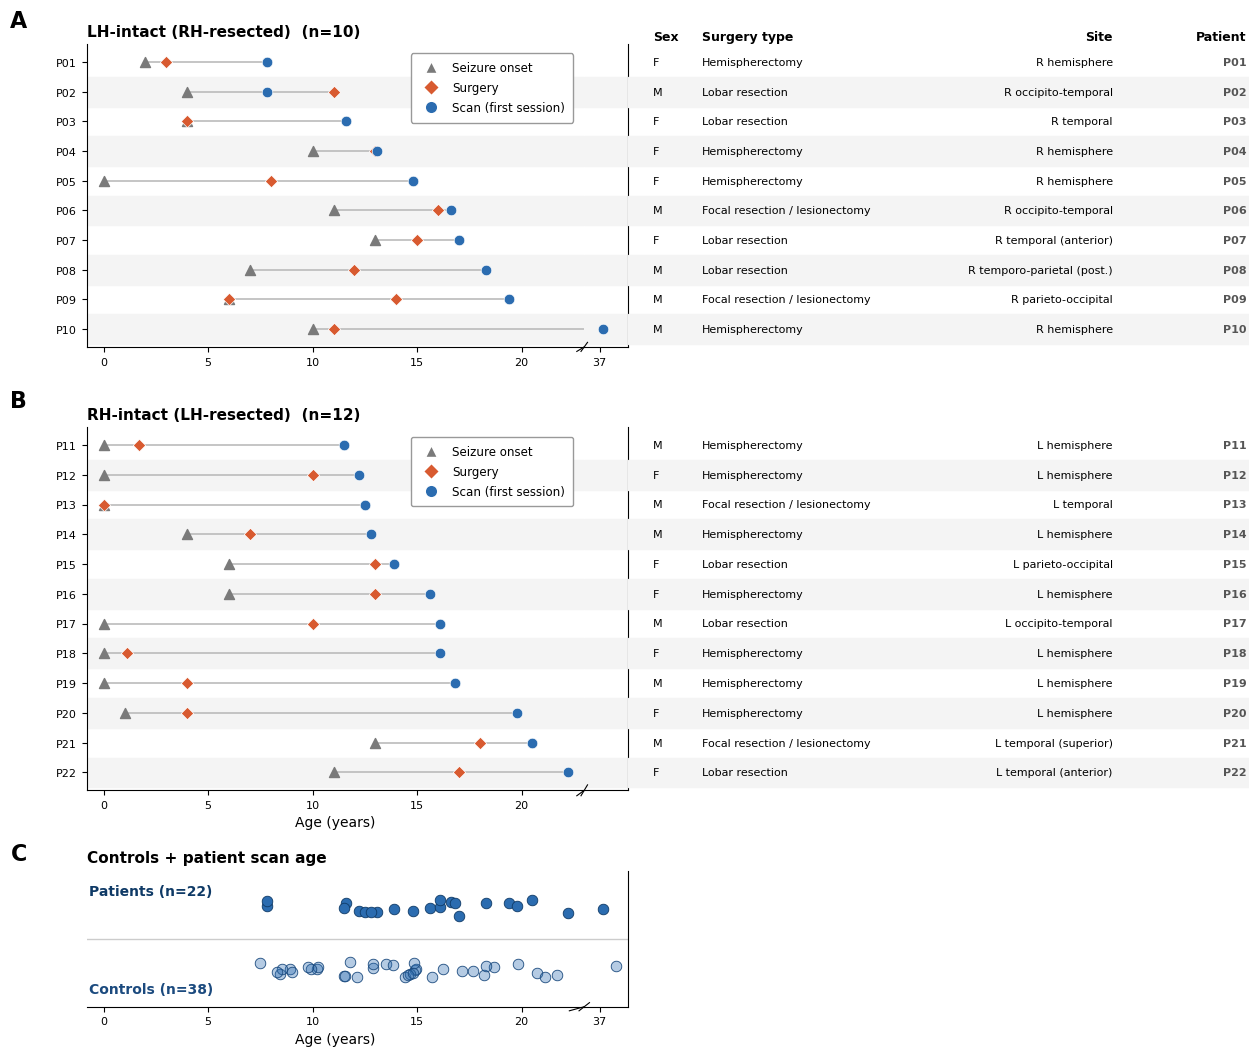

In [20]:
#!/usr/bin/env python
"""
Full cross-sectional figure, one canvas:
  A  LH-intact (RH-resected): timeline + metadata table
  B  RH-intact (LH-resected): timeline + metadata table
  C  Controls + patient scan age (jittered strip, enlarged text)
Shared age axis with a 37y break. White table background, alternating row bands.
"""
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ---- control ages: point at the live CSV on the cluster ----
CSV = "/user_data/csimmon2/git_repos/sym_pt/sub_info.csv"
CTRL_EXCLUDE = {"sub-027", "sub-084"}

C_SCAN  = "#2B6CB0"
C_EDGE_C= "#1B4A7E"   # control outline (slightly darker)
C_EDGE_P= "#0F3A66"   # patient outline (darker still)
C_SEIZ, C_SURG = "#7A7A7A", "#D85A30"
LINE, BAND = "#BBBBBB", "#F4F4F4"
MAIN_MAX, BRK_LO, BRK_HI = 23, 35.5, 39.7
rng = np.random.default_rng(7)

# (pid, sex, surgery, site, seizure, surgery_age, scan)
LH = [
    ("P01","F","Hemispherectomy",                "R hemisphere",                2.0,  3.0,  7.8),
    ("P02","M","Lobar resection",                "R occipito-temporal",         4.0, 11.0,  7.8),
    ("P03","F","Lobar resection",                "R temporal",                  4.0,  4.0, 11.6),
    ("P04","F","Hemispherectomy",                "R hemisphere",               10.0, 13.0, 13.1),
    ("P05","F","Hemispherectomy",                "R hemisphere",                0.0,  8.0, 14.8),
    ("P06","M","Focal resection / lesionectomy", "R occipito-temporal",        11.0, 16.0, 16.6),
    ("P07","F","Lobar resection",                "R temporal (anterior)",      13.0, 15.0, 17.0),
    ("P08","M","Lobar resection",                "R temporo-parietal (post.)",  7.0, 12.0, 18.3),
    ("P09","M","Focal resection / lesionectomy", "R parieto-occipital",         6.0,(6.0,14.0),19.4),
    ("P10","M","Hemispherectomy",                "R hemisphere",               10.0, 11.0, 37.3),
]
RH = [
    ("P11","M","Hemispherectomy",                "L hemisphere",                0.0,  1.7, 11.5),
    ("P12","F","Hemispherectomy",                "L hemisphere",                0.0, 10.0, 12.2),
    ("P13","M","Focal resection / lesionectomy", "L temporal",                  0.0,  0.0, 12.5),
    ("P14","M","Hemispherectomy",                "L hemisphere",                4.0,  7.0, 12.8),
    ("P15","F","Lobar resection",                "L parieto-occipital",         6.0, 13.0, 13.9),
    ("P16","F","Hemispherectomy",                "L hemisphere",                6.0, 13.0, 15.6),
    ("P17","M","Lobar resection",                "L occipito-temporal",         0.0, 10.0, 16.1),
    ("P18","F","Hemispherectomy",                "L hemisphere",                0.0,  1.1, 16.1),
    ("P19","M","Hemispherectomy",                "L hemisphere",                0.0,  4.0, 16.8),
    ("P20","F","Hemispherectomy",                "L hemisphere",                1.0,  4.0, 19.8),
    ("P21","M","Focal resection / lesionectomy", "L temporal (superior)",      13.0, 18.0, 20.5),
    ("P22","F","Lobar resection",                "L temporal (anterior)",      11.0, 17.0, 22.2),
]
PT_SCAN = np.array([r[6] for r in LH+RH])
COLX = {"Sex":0.04, "Surgery type":0.12, "Site":0.78, "Patient":0.995}

def split(a): return a[a<=MAIN_MAX], a[a>=BRK_LO]
def bands(ax, n):
    for r in range(n):
        if r % 2 == 0: ax.axhspan(r-0.5, r+0.5, color=BAND, zorder=0)
def panel_letter(ax, L):
    ax.text(-0.12, 1.04, L, transform=ax.transAxes, fontsize=16, fontweight="bold",
            va="bottom", ha="right")

def draw_timeline(axm, axb, rows, blank_break=False):
    n=len(rows); bands(axm,n); bands(axb,n)
    for i,row in enumerate(rows):
        pid,_,_,_,sz,su,sc=row; y=n-1-i
        su_list=list(su) if isinstance(su,(tuple,list)) else [su]
        axm.plot([min([sz]+su_list+[sc]), min(max([sz]+su_list+[sc]),MAIN_MAX)],[y,y],color=LINE,lw=1.2,zorder=1)
        for ax in (axm,axb):
            ax.scatter(sz,y,marker="^",s=52,color=C_SEIZ,zorder=3)
            for sv in su_list: ax.scatter(sv,y,marker="D",s=40,color=C_SURG,zorder=3,edgecolors="white",linewidths=.5)
            ax.scatter(sc,y,marker="o",s=58,color=C_SCAN,zorder=3,edgecolors="white",linewidths=.5)
    axm.set_yticks(range(n)); axm.set_yticklabels([r[0] for r in reversed(rows)],fontsize=8)
    axm.set_ylim(-0.6,n-0.4); axm.set_xlim(-0.8,MAIN_MAX)
    axb.set_xlim(BRK_LO,BRK_HI); axb.set_yticks([]); axb.set_ylim(-0.6,n-0.4)
    axb.set_xticks([] if blank_break else [37])
    axm.spines["right"].set_visible(False); axb.spines["left"].set_visible(False)
    for ax in (axm,axb): ax.spines["top"].set_visible(False); ax.tick_params(labelsize=8)
    d=.015; kw=dict(transform=axm.transAxes,color="k",clip_on=False,lw=.8)
    axm.plot((1-d,1+d),(-d,d),**kw); kw.update(transform=axb.transAxes); axb.plot((-d*5,d*5),(-d,d),**kw)

def draw_table(ax, rows, header=False):
    n=len(rows); bands(ax,n); ax.set_xlim(0,1); ax.set_ylim(-0.6,n-0.4); ax.axis("off")
    for i,row in enumerate(rows):
        pid,sex,surg,site=row[0],row[1],row[2],row[3]; y=n-1-i
        ax.text(COLX["Sex"],y,sex,ha="left",va="center",fontsize=8)
        ax.text(COLX["Surgery type"],y,surg,ha="left",va="center",fontsize=8)
        ax.text(COLX["Site"],y,site,ha="right",va="center",fontsize=8)
        ax.text(COLX["Patient"],y,pid,ha="right",va="center",fontsize=8,fontweight="bold",color="#555555")
    if header:
        for label,x in COLX.items():
            ha="right" if label in ("Site","Patient") else "left"
            ax.text(x,n-0.35,label,ha=ha,va="bottom",fontsize=9,fontweight="bold",clip_on=False)

def draw_strip(axm, axb):
    # enlarged text strip: patients (solid) up, controls (translucent) down
    df=pd.read_csv(CSV); ctrl=df[df["group"].str.lower()=="control"].copy()
    ctrl=ctrl[~ctrl["sub"].isin(CTRL_EXCLUDE)]
    ctrl["sesnum"]=ctrl["ses"].str.extract(r"(\d+)").astype(int)
    ctrl=ctrl.sort_values("sesnum").drop_duplicates("sub",keep="first")
    cage=ctrl["age"].values
    axm.axhline(0,color="#CCCCCC",lw=1,zorder=0); axb.axhline(0,color="#CCCCCC",lw=1,zorder=0)
    pm,pbk=split(PT_SCAN); cm,cbk=split(cage)
    axm.scatter(pm,0.45+rng.uniform(-.12,.12,len(pm)),s=58,color=C_SCAN,edgecolors=C_EDGE_P,linewidths=.6,zorder=3)
    axm.scatter(cm,-0.45+rng.uniform(-.12,.12,len(cm)),s=58,facecolors=(0.169,0.424,0.690,0.35),edgecolors=C_EDGE_C,linewidths=.6,zorder=3)
    axb.scatter(pbk,0.45+rng.uniform(-.05,.05,len(pbk)),s=58,color=C_SCAN,edgecolors=C_EDGE_P,linewidths=.6,zorder=3)
    axb.scatter(cbk,-0.45+rng.uniform(-.05,.05,len(cbk)),s=58,facecolors=(0.169,0.424,0.690,0.35),edgecolors=C_EDGE_C,linewidths=.6,zorder=3)
    axm.set_xlim(-0.8,MAIN_MAX); axb.set_xlim(BRK_LO,BRK_HI)
    for ax in (axm,axb):
        ax.set_ylim(-1,1); ax.set_yticks([]); ax.spines["top"].set_visible(False); ax.spines["left"].set_visible(False)
        ax.tick_params(labelsize=8)
    axm.spines["right"].set_visible(False); axb.spines["left"].set_visible(False); axb.set_xticks([37])
    d=.03; kw=dict(transform=axm.transAxes,color="k",clip_on=False,lw=.8)
    axm.plot((1-d,1+d),(-d,d),**kw); kw.update(transform=axb.transAxes); axb.plot((-d*4,d*4),(-d,d),**kw)
    axm.set_xlabel("Age (years)",fontsize=10)
    axm.text(0.005,.82,f"Patients (n={len(PT_SCAN)})",transform=axm.transAxes,fontsize=10,color=C_EDGE_P,fontweight="bold")
    axm.text(0.005,.10,f"Controls (n={len(cage)})",transform=axm.transAxes,fontsize=10,color=C_EDGE_C,fontweight="bold")

fig=plt.figure(figsize=(15,12.5))
gs=gridspec.GridSpec(3,3,width_ratios=[8,0.7,10],height_ratios=[10,12,4.5],wspace=0.0,hspace=0.30)
# A
axLm,axLb,axLt=fig.add_subplot(gs[0,0]),fig.add_subplot(gs[0,1]),fig.add_subplot(gs[0,2])
draw_timeline(axLm,axLb,LH); draw_table(axLt,LH,header=True)
axLm.set_title("LH-intact (RH-resected)  (n=10)",fontsize=11,fontweight="bold",loc="left"); panel_letter(axLm,"A")
# B
axRm,axRb,axRt=fig.add_subplot(gs[1,0]),fig.add_subplot(gs[1,1]),fig.add_subplot(gs[1,2])
draw_timeline(axRm,axRb,RH,blank_break=True); draw_table(axRt,RH)
axRm.set_title("RH-intact (LH-resected)  (n=12)",fontsize=11,fontweight="bold",loc="left"); panel_letter(axRm,"B")
axRm.set_xlabel("Age (years)",fontsize=10)
# C
axSm,axSb=fig.add_subplot(gs[2,0]),fig.add_subplot(gs[2,1])
draw_strip(axSm,axSb)
axSm.set_title("Controls + patient scan age",fontsize=11,fontweight="bold",loc="left"); panel_letter(axSm,"C")

handles=[
    plt.Line2D([],[],marker="^",color="w",markerfacecolor=C_SEIZ,ms=9,label="Seizure onset"),
    plt.Line2D([],[],marker="D",color="w",markerfacecolor=C_SURG,ms=8,label="Surgery"),
    plt.Line2D([],[],marker="o",color="w",markerfacecolor=C_SCAN,ms=9,label="Scan (first session)"),
]
for _ax in (axLm, axRm):
    _ax.legend(handles=handles, loc="upper right", bbox_to_anchor=(0.99, 0.99),
               ncol=1, fontsize=8.5, frameon=True, edgecolor="#999999", framealpha=1.0,
               borderpad=0.7, labelspacing=0.6)


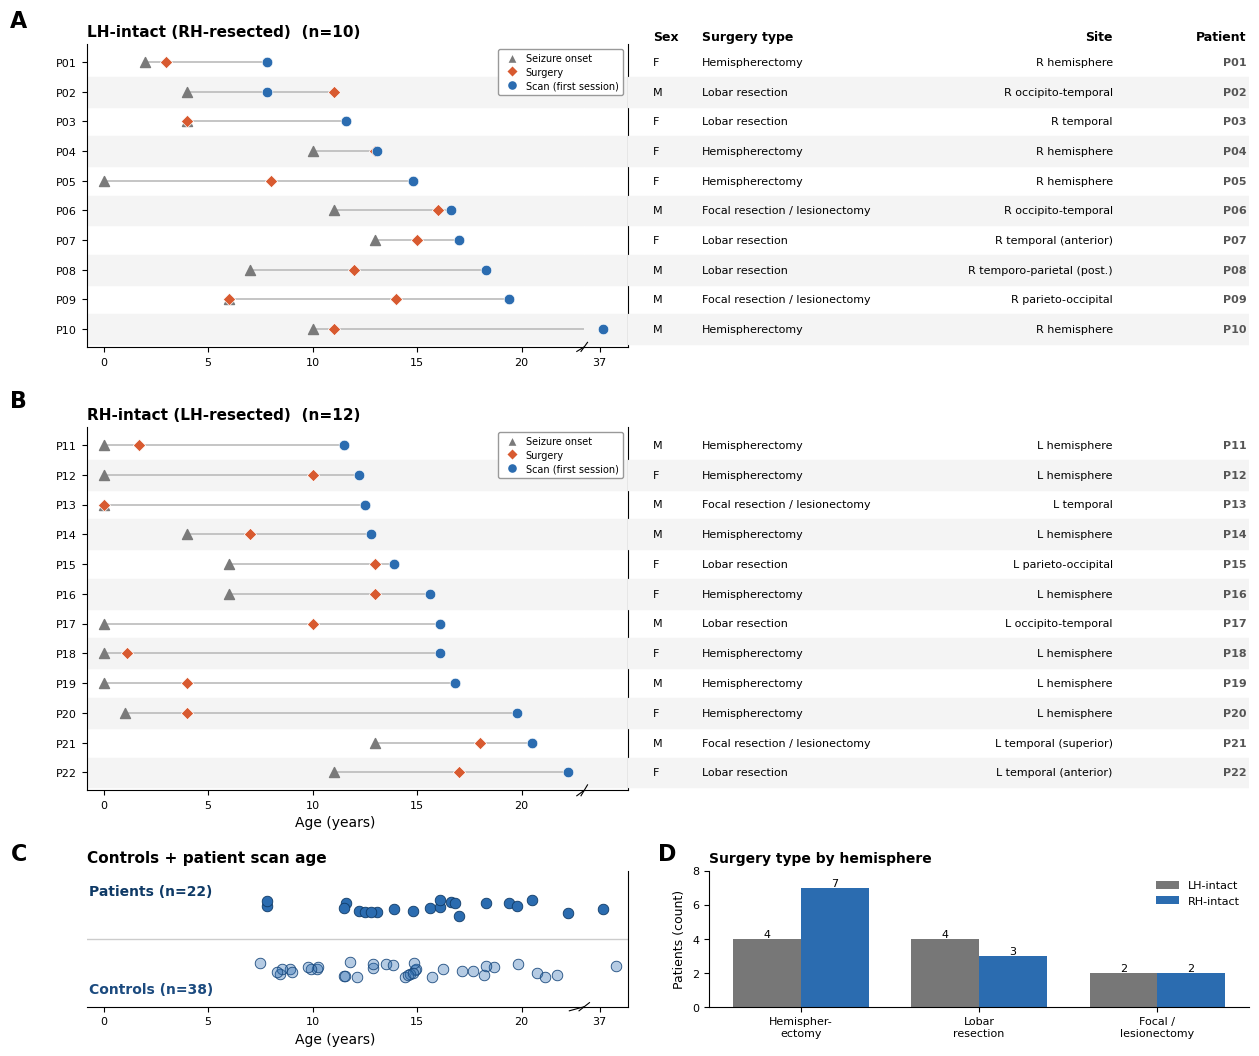

In [24]:
#!/usr/bin/env python
"""
Full cross-sectional figure, one canvas:
  A  LH-intact (RH-resected): timeline + metadata table
  B  RH-intact (LH-resected): timeline + metadata table
  C  Controls + patient scan age (jittered strip, enlarged text)
Shared age axis with a 37y break. White table background, alternating row bands.
"""
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ---- control ages: point at the live CSV on the cluster ----
CSV = "/user_data/csimmon2/git_repos/sym_pt/sub_info.csv"
CTRL_EXCLUDE = {"sub-027", "sub-084"}

C_SCAN  = "#2B6CB0"
C_EDGE_C= "#1B4A7E"   # control outline (slightly darker)
C_EDGE_P= "#0F3A66"   # patient outline (darker still)
C_SEIZ, C_SURG = "#7A7A7A", "#D85A30"
LINE, BAND = "#BBBBBB", "#F4F4F4"
MAIN_MAX, BRK_LO, BRK_HI = 23, 35.5, 39.7
rng = np.random.default_rng(7)

# (pid, sex, surgery, site, seizure, surgery_age, scan)
LH = [
    ("P01","F","Hemispherectomy",                "R hemisphere",                2.0,  3.0,  7.8),
    ("P02","M","Lobar resection",                "R occipito-temporal",         4.0, 11.0,  7.8),
    ("P03","F","Lobar resection",                "R temporal",                  4.0,  4.0, 11.6),
    ("P04","F","Hemispherectomy",                "R hemisphere",               10.0, 13.0, 13.1),
    ("P05","F","Hemispherectomy",                "R hemisphere",                0.0,  8.0, 14.8),
    ("P06","M","Focal resection / lesionectomy", "R occipito-temporal",        11.0, 16.0, 16.6),
    ("P07","F","Lobar resection",                "R temporal (anterior)",      13.0, 15.0, 17.0),
    ("P08","M","Lobar resection",                "R temporo-parietal (post.)",  7.0, 12.0, 18.3),
    ("P09","M","Focal resection / lesionectomy", "R parieto-occipital",         6.0,(6.0,14.0),19.4),
    ("P10","M","Hemispherectomy",                "R hemisphere",               10.0, 11.0, 37.3),
]
RH = [
    ("P11","M","Hemispherectomy",                "L hemisphere",                0.0,  1.7, 11.5),
    ("P12","F","Hemispherectomy",                "L hemisphere",                0.0, 10.0, 12.2),
    ("P13","M","Focal resection / lesionectomy", "L temporal",                  0.0,  0.0, 12.5),
    ("P14","M","Hemispherectomy",                "L hemisphere",                4.0,  7.0, 12.8),
    ("P15","F","Lobar resection",                "L parieto-occipital",         6.0, 13.0, 13.9),
    ("P16","F","Hemispherectomy",                "L hemisphere",                6.0, 13.0, 15.6),
    ("P17","M","Lobar resection",                "L occipito-temporal",         0.0, 10.0, 16.1),
    ("P18","F","Hemispherectomy",                "L hemisphere",                0.0,  1.1, 16.1),
    ("P19","M","Hemispherectomy",                "L hemisphere",                0.0,  4.0, 16.8),
    ("P20","F","Hemispherectomy",                "L hemisphere",                1.0,  4.0, 19.8),
    ("P21","M","Focal resection / lesionectomy", "L temporal (superior)",      13.0, 18.0, 20.5),
    ("P22","F","Lobar resection",                "L temporal (anterior)",      11.0, 17.0, 22.2),
]
PT_SCAN = np.array([r[6] for r in LH+RH])
COLX = {"Sex":0.04, "Surgery type":0.12, "Site":0.78, "Patient":0.995}

def split(a): return a[a<=MAIN_MAX], a[a>=BRK_LO]
def bands(ax, n):
    for r in range(n):
        if r % 2 == 0: ax.axhspan(r-0.5, r+0.5, color=BAND, zorder=0)
def panel_letter(ax, L, dx=-0.12):
    ax.text(dx, 1.04, L, transform=ax.transAxes, fontsize=16, fontweight="bold",
            va="bottom", ha="right")

def draw_timeline(axm, axb, rows, blank_break=False):
    n=len(rows); bands(axm,n); bands(axb,n)
    for i,row in enumerate(rows):
        pid,_,_,_,sz,su,sc=row; y=n-1-i
        su_list=list(su) if isinstance(su,(tuple,list)) else [su]
        axm.plot([min([sz]+su_list+[sc]), min(max([sz]+su_list+[sc]),MAIN_MAX)],[y,y],color=LINE,lw=1.2,zorder=1)
        for ax in (axm,axb):
            ax.scatter(sz,y,marker="^",s=52,color=C_SEIZ,zorder=3)
            for sv in su_list: ax.scatter(sv,y,marker="D",s=40,color=C_SURG,zorder=3,edgecolors="white",linewidths=.5)
            ax.scatter(sc,y,marker="o",s=58,color=C_SCAN,zorder=3,edgecolors="white",linewidths=.5)
    axm.set_yticks(range(n)); axm.set_yticklabels([r[0] for r in reversed(rows)],fontsize=8)
    axm.set_ylim(-0.6,n-0.4); axm.set_xlim(-0.8,MAIN_MAX)
    axb.set_xlim(BRK_LO,BRK_HI); axb.set_yticks([]); axb.set_ylim(-0.6,n-0.4)
    axb.set_xticks([] if blank_break else [37])
    axm.spines["right"].set_visible(False); axb.spines["left"].set_visible(False)
    for ax in (axm,axb): ax.spines["top"].set_visible(False); ax.tick_params(labelsize=8)
    d=.015; kw=dict(transform=axm.transAxes,color="k",clip_on=False,lw=.8)
    axm.plot((1-d,1+d),(-d,d),**kw); kw.update(transform=axb.transAxes); axb.plot((-d*5,d*5),(-d,d),**kw)

def draw_table(ax, rows, header=False):
    n=len(rows); bands(ax,n); ax.set_xlim(0,1); ax.set_ylim(-0.6,n-0.4); ax.axis("off")
    for i,row in enumerate(rows):
        pid,sex,surg,site=row[0],row[1],row[2],row[3]; y=n-1-i
        ax.text(COLX["Sex"],y,sex,ha="left",va="center",fontsize=8)
        ax.text(COLX["Surgery type"],y,surg,ha="left",va="center",fontsize=8)
        ax.text(COLX["Site"],y,site,ha="right",va="center",fontsize=8)
        ax.text(COLX["Patient"],y,pid,ha="right",va="center",fontsize=8,fontweight="bold",color="#555555")
    if header:
        for label,x in COLX.items():
            ha="right" if label in ("Site","Patient") else "left"
            ax.text(x,n-0.35,label,ha=ha,va="bottom",fontsize=9,fontweight="bold",clip_on=False)

def draw_strip(axm, axb):
    # enlarged text strip: patients (solid) up, controls (translucent) down
    df=pd.read_csv(CSV); ctrl=df[df["group"].str.lower()=="control"].copy()
    ctrl=ctrl[~ctrl["sub"].isin(CTRL_EXCLUDE)]
    ctrl["sesnum"]=ctrl["ses"].str.extract(r"(\d+)").astype(int)
    ctrl=ctrl.sort_values("sesnum").drop_duplicates("sub",keep="first")
    cage=ctrl["age"].values
    axm.axhline(0,color="#CCCCCC",lw=1,zorder=0); axb.axhline(0,color="#CCCCCC",lw=1,zorder=0)
    pm,pbk=split(PT_SCAN); cm,cbk=split(cage)
    axm.scatter(pm,0.45+rng.uniform(-.12,.12,len(pm)),s=58,color=C_SCAN,edgecolors=C_EDGE_P,linewidths=.6,zorder=3)
    axm.scatter(cm,-0.45+rng.uniform(-.12,.12,len(cm)),s=58,facecolors=(0.169,0.424,0.690,0.35),edgecolors=C_EDGE_C,linewidths=.6,zorder=3)
    axb.scatter(pbk,0.45+rng.uniform(-.05,.05,len(pbk)),s=58,color=C_SCAN,edgecolors=C_EDGE_P,linewidths=.6,zorder=3)
    axb.scatter(cbk,-0.45+rng.uniform(-.05,.05,len(cbk)),s=58,facecolors=(0.169,0.424,0.690,0.35),edgecolors=C_EDGE_C,linewidths=.6,zorder=3)
    axm.set_xlim(-0.8,MAIN_MAX); axb.set_xlim(BRK_LO,BRK_HI)
    for ax in (axm,axb):
        ax.set_ylim(-1,1); ax.set_yticks([]); ax.spines["top"].set_visible(False); ax.spines["left"].set_visible(False)
        ax.tick_params(labelsize=8)
    axm.spines["right"].set_visible(False); axb.spines["left"].set_visible(False); axb.set_xticks([37])
    d=.03; kw=dict(transform=axm.transAxes,color="k",clip_on=False,lw=.8)
    axm.plot((1-d,1+d),(-d,d),**kw); kw.update(transform=axb.transAxes); axb.plot((-d*4,d*4),(-d,d),**kw)
    axm.set_xlabel("Age (years)",fontsize=10)
    axm.text(0.005,.82,f"Patients (n={len(PT_SCAN)})",transform=axm.transAxes,fontsize=10,color=C_EDGE_P,fontweight="bold")
    axm.text(0.005,.10,f"Controls (n={len(cage)})",transform=axm.transAxes,fontsize=10,color=C_EDGE_C,fontweight="bold")


def draw_surgtype(ax):
    cats=["Hemispherectomy","Lobar resection","Focal resection / lesionectomy"]
    lh_c=[sum(r[2]==c for r in LH) for c in cats]
    rh_c=[sum(r[2]==c for r in RH) for c in cats]
    x=np.arange(len(cats)); w=0.38
    ax.bar(x-w/2,lh_c,w,label="LH-intact",color="#777777")
    ax.bar(x+w/2,rh_c,w,label="RH-intact",color=C_SCAN)
    for xi,(a,b) in enumerate(zip(lh_c,rh_c)):
        ax.text(xi-w/2,a+0.1,a,ha="center",fontsize=8)
        ax.text(xi+w/2,b+0.1,b,ha="center",fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(["Hemispher-\nectomy","Lobar\nresection","Focal /\nlesionectomy"],fontsize=8)
    ax.set_ylabel("Patients (count)",fontsize=9); ax.set_ylim(0,8)
    ax.legend(fontsize=8,frameon=False,loc="upper right")
    ax.spines[["top","right"]].set_visible(False); ax.tick_params(labelsize=8)

fig=plt.figure(figsize=(15,12.5))
gs=gridspec.GridSpec(3,3,width_ratios=[8,0.7,10],height_ratios=[10,12,4.5],wspace=0.0,hspace=0.30)
# A
axLm,axLb,axLt=fig.add_subplot(gs[0,0]),fig.add_subplot(gs[0,1]),fig.add_subplot(gs[0,2])
draw_timeline(axLm,axLb,LH); draw_table(axLt,LH,header=True)
axLm.set_title("LH-intact (RH-resected)  (n=10)",fontsize=11,fontweight="bold",loc="left"); panel_letter(axLm,"A")
# B
axRm,axRb,axRt=fig.add_subplot(gs[1,0]),fig.add_subplot(gs[1,1]),fig.add_subplot(gs[1,2])
draw_timeline(axRm,axRb,RH,blank_break=True); draw_table(axRt,RH)
axRm.set_title("RH-intact (LH-resected)  (n=12)",fontsize=11,fontweight="bold",loc="left"); panel_letter(axRm,"B")
axRm.set_xlabel("Age (years)",fontsize=10)
# C
axSm,axSb=fig.add_subplot(gs[2,0]),fig.add_subplot(gs[2,1])
draw_strip(axSm,axSb)
axSm.set_title("Controls + patient scan age",fontsize=11,fontweight="bold",loc="left"); panel_letter(axSm,"C")
ndg=gs[2,2].subgridspec(1,2,width_ratios=[1.2,8],wspace=0)
axD=fig.add_subplot(ndg[0,1]); draw_surgtype(axD)
axD.set_title("Surgery type by hemisphere",fontsize=10,fontweight="bold",loc="left")
panel_letter(axD,"D",dx=-0.06)

handles=[
    plt.Line2D([],[],marker="^",color="w",markerfacecolor=C_SEIZ,ms=9,label="Seizure onset"),
    plt.Line2D([],[],marker="D",color="w",markerfacecolor=C_SURG,ms=8,label="Surgery"),
    plt.Line2D([],[],marker="o",color="w",markerfacecolor=C_SCAN,ms=9,label="Scan (first session)"),
]
for _bk in (axLb, axRb):
    _bk.legend(handles=handles, loc="upper right", bbox_to_anchor=(1.0, 1.0),
               ncol=1, fontsize=7, frameon=True, edgecolor="#999999", framealpha=1.0,
               borderpad=0.45, labelspacing=0.35, handletextpad=0.4, markerscale=0.8)

controls n=38; age p=0.345; interval mean=6.7


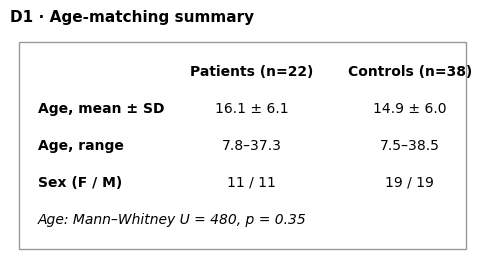

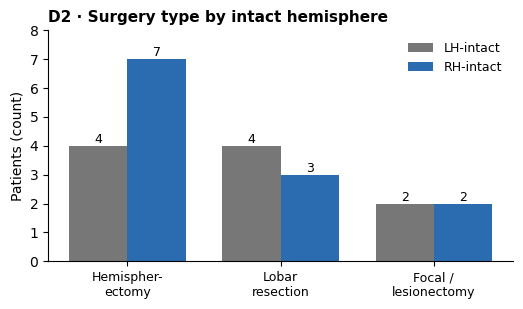

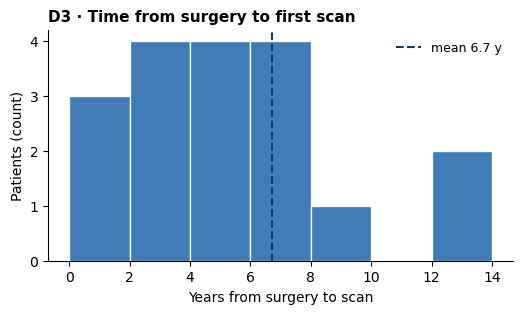

In [19]:
#!/usr/bin/env python
"""Three standalone options for panel D (bottom-right quadrant)."""
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

CSV="/user_data/csimmon2/git_repos/sym_pt/sub_info.csv"; CTRL_EXCLUDE={"sub-027","sub-084"}
C_SCAN="#2B6CB0"; C_EDGE_P="#0F3A66"; C_EDGE_C="#1B4A7E"
PAL={"face":"#378ADD","house":"#D85A30","object":"#639922","word":"#EF9F27"}

# patient data (pid, sex, surgery_cat, site, seizure, surgery_age, scan)
LH=[("P01","F","Hemispherectomy",2.0,3.0,7.8),("P02","M","Lobar",4.0,11.0,7.8),
    ("P03","F","Lobar",4.0,4.0,11.6),("P04","F","Hemispherectomy",10.0,13.0,13.1),
    ("P05","F","Hemispherectomy",0.0,8.0,14.8),("P06","M","Focal",11.0,16.0,16.6),
    ("P07","F","Lobar",13.0,15.0,17.0),("P08","M","Lobar",7.0,12.0,18.3),
    ("P09","M","Focal",6.0,14.0,19.4),("P10","M","Hemispherectomy",10.0,11.0,37.3)]
RH=[("P11","M","Hemispherectomy",0.0,1.7,11.5),("P12","F","Hemispherectomy",0.0,10.0,12.2),
    ("P13","M","Focal",0.0,0.0,12.5),("P14","M","Hemispherectomy",4.0,7.0,12.8),
    ("P15","F","Lobar",6.0,13.0,13.9),("P16","F","Hemispherectomy",6.0,13.0,15.6),
    ("P17","M","Lobar",0.0,10.0,16.1),("P18","F","Hemispherectomy",0.0,1.1,16.1),
    ("P19","M","Hemispherectomy",0.0,4.0,16.8),("P20","F","Hemispherectomy",1.0,4.0,19.8),
    ("P21","M","Focal",13.0,18.0,20.5),("P22","F","Lobar",11.0,17.0,22.2)]
pt_age=np.array([r[5] for r in LH+RH]); pt_sex=[r[1] for r in LH+RH]
pt_surg=np.array([r[4] for r in LH+RH]); pt_interval=pt_age-pt_surg

df=pd.read_csv(CSV); ctrl=df[df["group"].str.lower()=="control"].copy()
ctrl=ctrl[~ctrl["sub"].isin(CTRL_EXCLUDE)]
ctrl["sesnum"]=ctrl["ses"].str.extract(r"(\d+)").astype(int)
ctrl=ctrl.sort_values("sesnum").drop_duplicates("sub",keep="first")
c_age=ctrl["age"].values; c_sex=ctrl["sex"].str[0].str.upper().values
U,p=mannwhitneyu(pt_age,c_age,alternative="two-sided")

# counts surgery x hemi
cats=["Hemispherectomy","Lobar","Focal"]
lh_c={c:sum(r[2]==c for r in LH) for c in cats}; rh_c={c:sum(r[2]==c for r in RH) for c in cats}

# ===== D1: age-matching stats box =====
f1,ax=plt.subplots(figsize=(6,3)); ax.axis("off")
ax.add_patch(plt.Rectangle((0.02,0.05),0.96,0.9,fill=False,edgecolor="#999999",lw=1,transform=ax.transAxes))
lines=[
  ("", "Patients (n=22)", "Controls (n=38)"),
  ("Age, mean ± SD", f"{pt_age.mean():.1f} ± {pt_age.std(ddof=1):.1f}", f"{c_age.mean():.1f} ± {c_age.std(ddof=1):.1f}"),
  ("Age, range", f"{pt_age.min():.1f}–{pt_age.max():.1f}", f"{c_age.min():.1f}–{c_age.max():.1f}"),
  ("Sex (F / M)", f"{pt_sex.count('F')} / {pt_sex.count('M')}", f"{(c_sex=='F').sum()} / {(c_sex=='M').sum()}"),
]
y=0.82
for i,(a,b,c) in enumerate(lines):
    fw="bold" if i==0 else "normal"
    ax.text(0.06,y,a,fontsize=10,fontweight="bold",va="center")
    ax.text(0.52,y,b,fontsize=10,fontweight=fw,va="center",ha="center")
    ax.text(0.86,y,c,fontsize=10,fontweight=fw,va="center",ha="center")
    y-=0.16
ax.text(0.06,y,f"Age: Mann–Whitney U = {U:.0f}, p = {p:.2f}",fontsize=10,va="center",style="italic")
ax.set_title("D1 · Age-matching summary",fontsize=11,fontweight="bold",loc="left")

# ===== D2: surgery-type x hemisphere counts =====
f2,ax=plt.subplots(figsize=(6,3))
x=np.arange(len(cats)); w=0.38
ax.bar(x-w/2,[lh_c[c] for c in cats],w,label="LH-intact",color="#777777")
ax.bar(x+w/2,[rh_c[c] for c in cats],w,label="RH-intact",color=C_SCAN)
for xi,c in zip(x,cats):
    ax.text(xi-w/2,lh_c[c]+0.1,lh_c[c],ha="center",fontsize=9)
    ax.text(xi+w/2,rh_c[c]+0.1,rh_c[c],ha="center",fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(["Hemispher-\nectomy","Lobar\nresection","Focal /\nlesionectomy"],fontsize=9)
ax.set_ylabel("Patients (count)",fontsize=10); ax.set_ylim(0,8)
ax.legend(fontsize=9,frameon=False); ax.spines[["top","right"]].set_visible(False)
ax.set_title("D2 · Surgery type by intact hemisphere",fontsize=11,fontweight="bold",loc="left")

# ===== D3: surgery->scan interval distribution =====
f3,ax=plt.subplots(figsize=(6,3))
ax.hist(pt_interval,bins=np.arange(0,16,2),color=C_SCAN,edgecolor="white",alpha=.9)
ax.axvline(pt_interval.mean(),color=C_EDGE_P,lw=1.5,ls="--",label=f"mean {pt_interval.mean():.1f} y")
ax.set_xlabel("Years from surgery to scan",fontsize=10); ax.set_ylabel("Patients (count)",fontsize=10)
ax.legend(fontsize=9,frameon=False); ax.spines[["top","right"]].set_visible(False)
ax.set_title("D3 · Time from surgery to first scan",fontsize=11,fontweight="bold",loc="left")
print(f"controls n={len(c_age)}; age p={p:.3f}; interval mean={pt_interval.mean():.1f}")

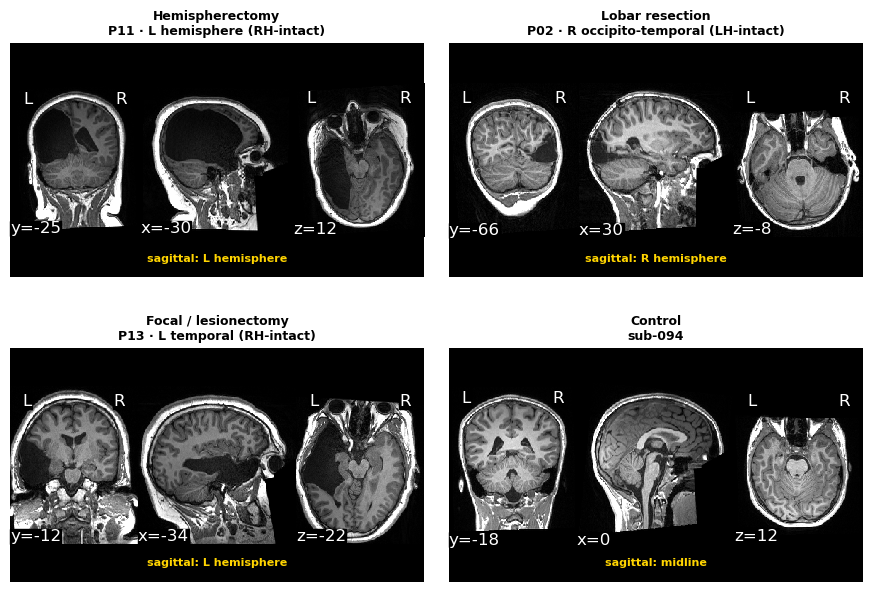

In [27]:
#!/usr/bin/env python
"""
Representative anatomy figure: one exemplar per surgery type + one control = 4 panels (2x2).
RUN ON THE CLUSTER. Cut coords are starting guesses — tune against each scan.
Heads equalized by tight head-bbox crop (world coords preserved). Sagittal (middle)
view labeled with its hemisphere (from cut x-sign).
"""
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib import gridspec
from nilearn import image, plotting

RAW_DIR = "/lab_data/behrmannlab/hemi/Raw"     # adjust if T1s live elsewhere
SES = "ses-01"
T1  = "{raw}/{sub}/{ses}/anat/{sub}_{ses}_T1w.nii.gz"
DIM = -1.25

# (row, col, sub, title two-line, (x,y,z) cut)
PANELS = [
    (0,0,"sub-099","Hemispherectomy\nP11 · L hemisphere (RH-intact)",   (-30,-25, 12)),
    (0,1,"sub-004","Lobar resection\nP02 · R occipito-temporal (LH-intact)", ( 30,-66, -8)),
    (1,0,"sub-044","Focal / lesionectomy\nP13 · L temporal (RH-intact)", (-34,-12,-22)),
    (1,1,"sub-094","Control\nsub-094",                                   (  0,-18, 12)),
]

def tight_crop(img, frac=0.12, pad=6):
    d = img.get_fdata()
    thr = frac * np.percentile(d, 99.5)
    mask = d > thr
    if mask.sum() == 0: return img
    idx = np.array(np.where(mask))
    lo = np.clip(idx.min(1) - pad, 0, None)
    hi = np.minimum(idx.max(1) + pad + 1, d.shape)
    sl = tuple(slice(int(a), int(b)) for a, b in zip(lo, hi))
    aff = img.affine.copy()
    aff[:3, 3] = aff[:3, 3] + aff[:3, :3].dot(lo)
    return nib.Nifti1Image(d[sl], aff)

def show(ax, sub, title, cut):
    path = T1.format(raw=RAW_DIR, sub=sub, ses=SES)
    if not os.path.exists(path):
        ax.text(0.5,0.5,f"{title}\n(T1 not found)",ha="center",va="center",fontsize=9); ax.axis("off"); return
    anat = tight_crop(image.load_img(path))
    plotting.plot_anat(anat, cut_coords=cut, draw_cross=False, dim=DIM, axes=ax, annotate=True)
    ax.set_title(title, fontsize=9, fontweight="bold")
    sag = "midline" if abs(cut[0]) < 5 else ("R hemisphere" if cut[0] > 0 else "L hemisphere")
    ax.text(0.5, 0.06, f"sagittal: {sag}", transform=ax.transAxes, ha="center", va="bottom",
            fontsize=8, fontweight="bold", color="#FFD400")

fig = plt.figure(figsize=(11, 7))
gs = gridspec.GridSpec(2, 2, hspace=0.30, wspace=0.06)
for r, c, sub, title, cut in PANELS:
    show(fig.add_subplot(gs[r, c]), sub, title, cut)